In [26]:
# Perform customer segmentation using K-Means clustering and visualise results using PCA.
# Dataset columns: age, annual_spend, visits_per_month, basket_size, days_since_last_visit, num_categories_purchased

# Task 1 - Data Preparation
# Load q2_customers.csv. Scale all features using StandardScaler. 
# In a markdown cell, explain why scaling is essential before applying K-Means.

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = pd.read_csv('../data/q2_customers.csv')

# Select features for clustering
features = data[['age', 'annual_spend', 'visits_per_month', 'basket_size', 'days_since_last_visit', 'num_categories_purchased']]

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)



## Task 1 - Scaling before K-Means

## Why is scaling essential before applying K-Means?

Scaling is essential before applying K-Means because K-Means relies on the distance between data points to form clusters.
If the features are on different scales, K-Means may give more weight to features with larger ranges, 
leading to biased clustering results. Scaling ensures that all features contribute equally to the distance calculations.

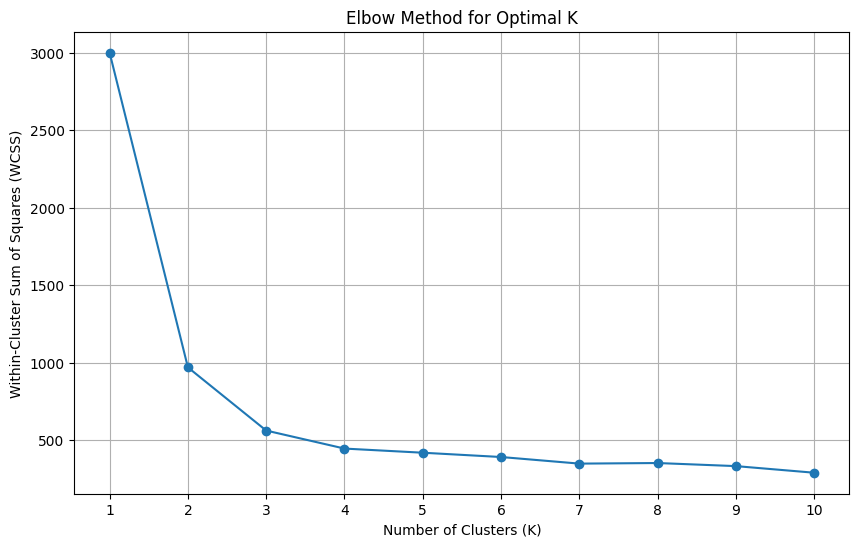

In [27]:
# Task 2 - Choosing K — Elbow Method
# Compute and plot the Within-Cluster Sum of Squares (WCSS) for K = 1 through 10. 
# Identify the optimal K from the elbow point and justify your selection in a markdown cell.

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Compute WCSS for K = 1 to 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot WCSS
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid()
plt.show()



## Task 2 - Choosing K: Elbow Method

Looking at the WCSS plot, the curve shows a significant drop from K=1 to K=3, 
after which the rate of decrease slows down considerably. The "elbow" point 
appears at **K=3**, where adding more clusters gives diminishing returns in 
reducing WCSS.

Therefore, **K=3** is selected as the optimal number of clusters, as it 
provides a good balance between model complexity and cluster compactness.

In [28]:
# Task 3 - K-Means Clustering
# Fit K-Means with your chosen K
# Fit K-Means with the optimal K (let's assume we chose K=3 based on the elbow method)

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(scaled_features)

# Add a cluster column to the dataframe
data['cluster'] = kmeans.labels_

# Print the cluster centroids as a readable dataframe
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features.columns)
print("Cluster Centroids:")
print(centroids)



Cluster Centroids:
         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


# Task 3 - Interpreting each cluster in business terms

- Cluster 0: Young (~25), low spenders (~$15k), frequent visitors, small baskets — "Young Budget Shoppers"
- Cluster 1: Older (~57), high spenders (~$89k), infrequent visitors, large baskets — "Wealthy Occasional Shoppers"  
- Cluster 2: Middle-aged (~40), moderate spenders (~$43k), moderate visitors — "Regular Mid-range Shoppers"

In [29]:
# Task 4 - Dimensionality Reduction with PCA
# Apply PCA to reduce the data to 2 principal components

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

# Print the explained variance ratio for each component
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance Ratio: {explained_variance}")

# Print the feature loadings (components) as a readable dataframe
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features.columns)
print("PCA Loadings:")
print(loadings)



Explained Variance Ratio: [0.83560354 0.05568764]
PCA Loadings:
                               PC1       PC2
age                       0.411569 -0.259432
annual_spend              0.421540 -0.033270
visits_per_month         -0.410399  0.208318
basket_size               0.412012 -0.195402
days_since_last_visit     0.378582  0.911194
num_categories_purchased  0.414017 -0.140479


# Task 4 - Interpret PC1 and PC2 capture based on the loading (PCA Interpretation)

**Explained Variance:**
- PC1 explains 83.6% of the variance, capturing most of the information in the data.
- PC2 explains only 5.6% of the variance.
- Together they explain 89.1% of the total variance.

**PC1 Interpretation:**
PC1 has high positive loadings on age, annual_spend, basket_size, and 
num_categories_purchased, and a high negative loading on visits_per_month. 
This means PC1 represents overall customer value — high PC1 scores indicate 
older, high-spending customers who visit less frequently but spend more per visit.

**PC2 Interpretation:**
PC2 is dominated by days_since_last_visit (loading of 0.91), meaning it 
primarily captures customer recency — how long ago a customer last visited. 
High PC2 scores indicate customers who haven't visited in a long time.

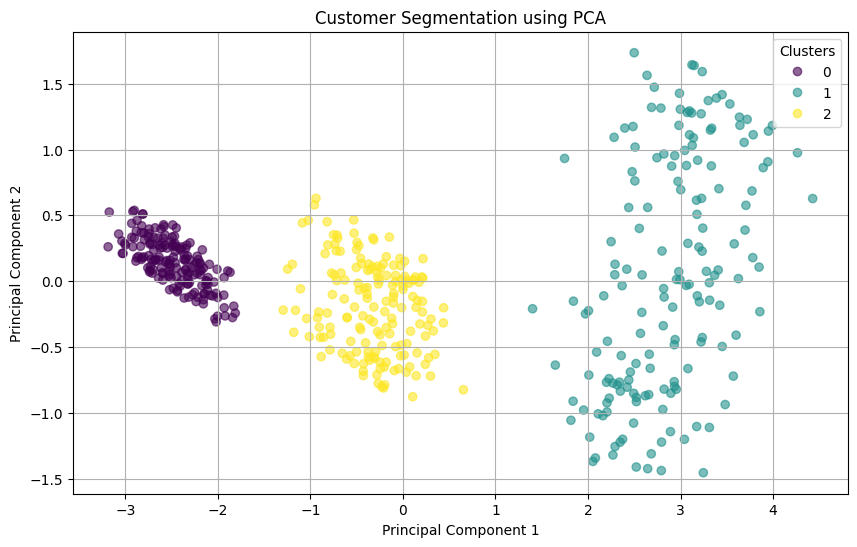

In [30]:
# Task 5 - Cluster Visualisation
# Create a scatter plot of PC1 vs PC2 with points coloured by cluster label. Include a title, axis labels, and a legend.

plt.figure(figsize=(10, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=data['cluster'], cmap='viridis', alpha=0.6)
plt.title('Customer Segmentation using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter.legend_elements(), title='Clusters')
plt.grid()
plt.show()